In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, ParameterGrid
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [8]:
# loading in data
def load_training_data(data_dir="data"):
    X_raw = np.load(os.path.join(data_dir, "train_tabular.npy"), allow_pickle=True)
    y = np.load(os.path.join(data_dir, "train_labels.npy"))
    ids = np.load(os.path.join(data_dir, "train_ids.npy"), allow_pickle=True)
    return X_raw, y, ids

# NOTE: test data not currently available, but here is framework
def load_test_data(test_name="test1", data_dir="data"):
    X_test_raw = np.load(os.path.join(data_dir, f"{test_name}_tabular.npy"), allow_pickle=True)
    test_ids = np.load(os.path.join(data_dir, f"{test_name}_ids.npy"), allow_pickle=True)
    return X_test_raw, test_ids

# preprocessing
def fit_preprocessors(X_train_raw):
    df = pd.DataFrame(X_train_raw, columns=["age", "sex", "anatomical_site"])
    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    age_median = df["age"].median()
    df["age"] = df["age"].fillna(age_median)

    sex_encoder = LabelEncoder()
    site_encoder = LabelEncoder()
    df["sex"] = sex_encoder.fit_transform(df["sex"].astype(str))
    df["anatomical_site"] = site_encoder.fit_transform(df["anatomical_site"].astype(str))

    return df.values, age_median, sex_encoder, site_encoder

def transform_with_preprocessors(X_raw, age_median, sex_encoder, site_encoder):
    df = pd.DataFrame(X_raw, columns=["age", "sex", "anatomical_site"])
    df["age"] = pd.to_numeric(df["age"], errors="coerce").fillna(age_median)
    df["sex"] = sex_encoder.transform(df["sex"].astype(str))
    df["anatomical_site"] = site_encoder.transform(df["anatomical_site"].astype(str))

    return df.values

# data split
def make_train_val_split(X_raw, y, ids, test_size=0.2, random_state=42):
    return train_test_split(
        X_raw,
        y,
        ids,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
        shuffle=True,
    )

# GBM model
def build_gbm(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=2,
    min_samples_split=2,
    min_samples_leaf=1,
    subsample=1.0,
    random_state=42,
):
    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        subsample=subsample,
        random_state=random_state,
    )
    return model


def evaluate_model(model, X_val, y_val):
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)

    metrics = {
        "accuracy": accuracy_score(y_val, y_pred),
        "precision_macro": precision_score(y_val, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_val, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_val, y_pred, average="macro"),
        "f1_weighted": f1_score(y_val, y_pred, average="weighted"),
    }

    print("\nValidation Metrics")
    metrics_df = pd.DataFrame([metrics])
    print(metrics_df.round(4))

    print("\nClassification Report")
    print(classification_report(y_val, y_pred))

    return metrics, y_pred, y_proba


def plot_feature_importance(model, feature_names=None, save_path=None):
    if feature_names is None:
        feature_names = ["age", "sex", "anatomical_site"]

    importances = model.feature_importances_

    plt.figure(figsize=(8, 5))
    plt.bar(feature_names, importances)
    plt.title("GBM Feature Importances")
    plt.xlabel("Feature")
    plt.ylabel("Importance")

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

def plot_confusion_matrix(model, X_val, y_val, save_path=None):
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title("GBM Validation Confusion Matrix")

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

def tune_gbm(X_train, y_train):
    print("\n[GBM] Starting hyperparameter tuning...")

    gbm = GradientBoostingClassifier(random_state=42)

    param_grid = {
        "n_estimators": [50, 100, 150, 200],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "max_depth": [1, 2, 3],
        "subsample": [0.8, 1.0],
    }

    total_candidates = (
        len(param_grid["n_estimators"]) *
        len(param_grid["learning_rate"]) *
        len(param_grid["max_depth"])
    )

    cv_folds = 3
    total_candidates = len(list(ParameterGrid(param_grid)))
    total_fits = total_candidates * cv_folds

    print(f"[GBM] Total candidates: {total_candidates}")
    print(f"[GBM] Total fits (with CV): {total_fits}\n")

    grid = GridSearchCV(
        estimator=gbm,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=3,
        n_jobs=-1,
        verbose=3   # <-- shows iteration progress
    )

    grid.fit(X_train, y_train)

    print("\n[GBM] Best parameters:", grid.best_params_)
    print("[GBM] Best CV macro F1:", grid.best_score_)

    return grid.best_estimator_, grid.best_params_, grid.best_score_


# NOTE: At the moment, unused
# function is just an idea of how we could submit this
def make_submission(model, age_median, sex_encoder, site_encoder,
                    test_name="test1", data_dir="data", output_csv=None):
    X_test_raw, test_ids = load_test_data(test_name=test_name, data_dir=data_dir)
    X_test = transform_with_preprocessors(X_test_raw, age_median, sex_encoder, site_encoder)

    preds = model.predict(X_test)

    submission = pd.DataFrame({
        "ID": test_ids,
        "label": preds.astype(int),
    })

    if output_csv is None:
        output_csv = f"gbm_{test_name}_submission.csv"

    submission.to_csv(output_csv, index=False)
    print(f"\nSaved submission to: {output_csv}")

    return submission

# NOTE: another idea check of how we could submit once we have test data
def test_files_exist(test_name="test1", data_dir="data"):
    tab_path = os.path.join(data_dir, f"{test_name}_tabular.npy")
    id_path = os.path.join(data_dir, f"{test_name}_ids.npy")
    return os.path.exists(tab_path) and os.path.exists(id_path)


Raw training data shape: (3500, 3)
Labels shape: (3500,)
Processed X_train shape: (2800, 3)
Processed X_val shape: (700, 3)

[GBM] Starting hyperparameter tuning...
[GBM] Total candidates: 96
[GBM] Total fits (with CV): 288

Fitting 3 folds for each of 96 candidates, totalling 288 fits

[GBM] Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
[GBM] Best CV macro F1: 0.19877153011200985

Validation Metrics
   accuracy  precision_macro  recall_macro  f1_macro  f1_weighted
0    0.6529           0.2739        0.2236    0.2356       0.6014

Classification Report
              precision    recall  f1-score   support

           0       0.18      0.12      0.14        77
           1       0.33      0.20      0.25        41
           2       0.25      0.12      0.17        24
           3       0.26      0.10      0.15        77
           4       0.75      0.92      0.83       463
           5       0.00      0.00      0.00         8
           6 

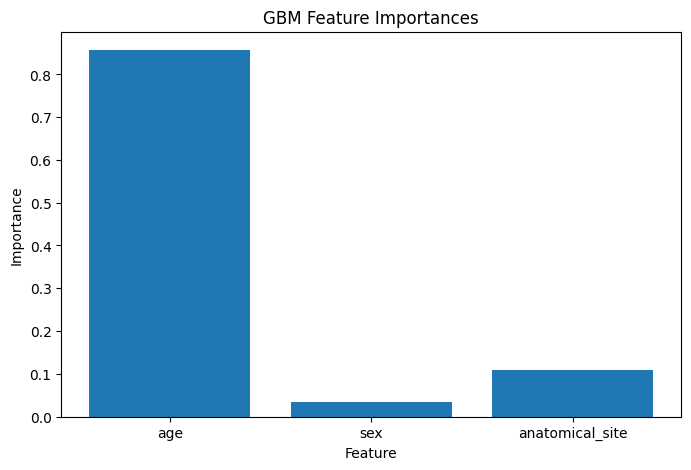

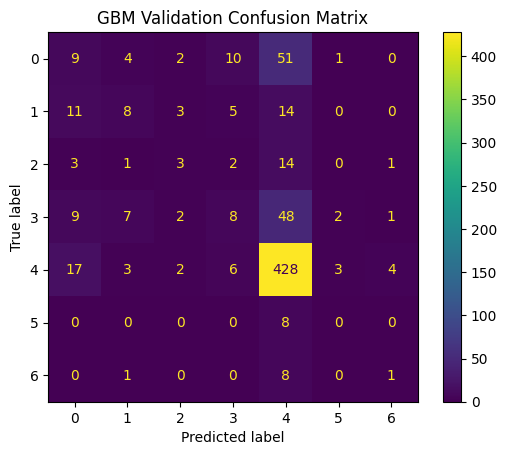


 test1 files not found.

 test2 files not found.


In [9]:
def main():
    X_raw, y, ids = load_training_data(data_dir="data")
    print("Raw training data shape:", X_raw.shape)
    print("Labels shape:", y.shape)

    X_train_raw, X_val_raw, y_train, y_val, train_ids, val_ids = make_train_val_split(
        X_raw, y, ids, test_size=0.2, random_state=42
    )

    # preprocessing
    X_train, age_median, sex_encoder, site_encoder = fit_preprocessors(X_train_raw)
    X_val = transform_with_preprocessors(X_val_raw, age_median, sex_encoder, site_encoder)
    print("Processed X_train shape:", X_train.shape)
    print("Processed X_val shape:", X_val.shape)

    # model fit
    gbm, best_params, best_score = tune_gbm(X_train, y_train)
    gbm.fit(X_train, y_train)
    metrics, y_pred, y_proba = evaluate_model(gbm, X_val, y_val)

    # saving results for later fusion
    val_results = pd.DataFrame({
        "ID": val_ids,
        "true_label": y_val,
        "gbm_pred": y_pred,
    })
    for c in range(y_proba.shape[1]):
        val_results[f"gbm_prob_{c}"] = y_proba[:, c]

  # saving results to csv (for now)
    val_results.to_csv("gbm_val_predictions.csv", index=False)
    print("\nSaved validation probabilities to: gbm_val_predictions.csv")

    plot_feature_importance(gbm, feature_names=["age", "sex", "anatomical_site"])
    plot_confusion_matrix(gbm, X_val, y_val)

    # NOTE: also unused for now
    # idea of how we could submit
    if test_files_exist(test_name="test1", data_dir="data"):
        make_submission(
            gbm,
            age_median,
            sex_encoder,
            site_encoder,
            test_name="test1",
            data_dir="data",
            output_csv="gbm_test1_submission.csv",
        )
    else:
        print("\n test1 files not found.")

    if test_files_exist(test_name="test2", data_dir="data"):
        make_submission(
            gbm,
            age_median,
            sex_encoder,
            site_encoder,
            test_name="test2",
            data_dir="data",
            output_csv="gbm_test2_submission.csv",
        )
    else:
        print("\n test2 files not found.")


if __name__ == "__main__":
    main()